# PyTorch Puro — Tutorial Avanzado

Este notebook es el equivalente directo del tutorial de PyTorch Lightning, implementado en **PyTorch puro**. El objetivo es que puedas comparar ambos lado a lado y entender exactamente qué automatiza Lightning y qué estás escribiendo tú mismo.

### Estructura

| Paso | Tema | Equivalente en Lightning |
|---|---|---|
| 1 | Reproducibilidad | `pl.seed_everything` |
| 2 | Dataset y DataLoaders | `LightningDataModule` |
| 3 | Modelo | `LightningModule` |
| 4 | Loop de entrenamiento manual | `Trainer.fit` |
| 5 | Scheduler | `configure_optimizers` |
| 6 | Early Stopping | `EarlyStopping` callback |
| 7 | Checkpointing | `ModelCheckpoint` callback |
| 8 | Logging de métricas | `CSVLogger` |
| 9 | Evaluación y carga de checkpoint | `trainer.test` + `load_from_checkpoint` |
| 10 | Comparación de experimentos | múltiples runs |

### Lo que escribes tú vs. lo que hace Lightning

| Responsabilidad | PyTorch puro | Lightning |
|---|---|---|
| `zero_grad / backward / step` | ✅ tú | automático |
| Mover tensores al device | ✅ tú | automático |
| `model.train()` / `model.eval()` | ✅ tú | automático |
| Acumular métricas por época | ✅ tú | automático |
| Early stopping | ✅ tú | callback |
| Guardar checkpoints | ✅ tú | callback |
| Loop de validación | ✅ tú | automático |

> **Prerequisito:** Conocimiento básico de tensores PyTorch y `nn.Module`.

---
## Paso 0 — Instalación

In [ ]:
# !pip install torch torchvision

In [1]:
import os
import csv
import copy
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print('PyTorch version :', torch.__version__)
print('GPU disponible  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU             :', torch.cuda.get_device_name(0))

PyTorch version : 2.8.0+cu128
GPU disponible  : True
GPU             : Tesla T4


---
## Paso 1 — Reproducibilidad

Lightning hace esto con una sola llamada: `pl.seed_everything(42, workers=True)`.  
En PyTorch puro tienes que fijar la semilla en **cada librería por separado**.

In [2]:
def seed_everything(seed: int):
    """Fija la semilla en Python, NumPy, y PyTorch (CPU + GPU)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Operaciones deterministas en CUDA (pequeño costo de velocidad)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED']        = str(seed)
    print(f'Semilla fijada: {seed}')

seed_everything(42)

Semilla fijada: 42


---
## Paso 2 — Device

En Lightning el `Trainer` mueve todo al device automáticamente.  
En PyTorch puro **tú eres responsable** de mover cada tensor y el modelo.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando device:', device)

# Regla de oro: mueve el modelo una vez al inicio,
# y cada batch de datos dentro del loop de entrenamiento.

Usando device: cuda


---
## Paso 3 — Data

Lightning encapsula todo esto en un `LightningDataModule` con métodos `prepare_data`, `setup`, y `*_dataloader`.  
Aquí escribimos lo mismo como una clase Python estándar para mantener el mismo orden y claridad.

In [4]:
class MNISTDataModule:
    """
    Encapsula toda la lógica de datos para MNIST.
    Equivalente directo al LightningDataModule del tutorial anterior.
    """

    def __init__(self, data_dir='./data', batch_size=512, num_workers=4, val_split=0.1):
        self.data_dir    = data_dir
        self.batch_size  = batch_size
        self.num_workers = num_workers
        self.val_split   = val_split

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.1307,), std=(0.3081,)),
        ])

    def prepare_data(self):
        """Descarga los datos. Solo escribe en disco, no asigna estado."""
        datasets.MNIST(self.data_dir, train=True,  download=True)
        datasets.MNIST(self.data_dir, train=False, download=True)

    def setup(self):
        """Carga en memoria, aplica splits y transforms."""
        full_train = datasets.MNIST(self.data_dir, train=True,  transform=self.transform)
        test_set   = datasets.MNIST(self.data_dir, train=False, transform=self.transform)

        val_size   = int(len(full_train) * self.val_split)
        train_size = len(full_train) - val_size
        self.train_set, self.val_set = random_split(full_train, [train_size, val_size])
        self.test_set = test_set

        print(f'Train: {len(self.train_set)}  Val: {len(self.val_set)}  Test: {len(self.test_set)}')

    def train_dataloader(self):
        return DataLoader(
            self.train_set,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_set,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_set,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=True,
        )


dm = MNISTDataModule(batch_size=512, num_workers=os.cpu_count() // 2)
dm.prepare_data()
dm.setup()

batch = next(iter(dm.train_dataloader()))
print('Batch shape :', batch[0].shape)
print('Label shape :', batch[1].shape)

Train: 54000  Val: 6000  Test: 10000
Batch shape : torch.Size([512, 1, 28, 28])
Label shape : torch.Size([512])


---
## Paso 4 — Modelo

El modelo es un `nn.Module` estándar — exactamente igual que en Lightning.  
La diferencia es que aquí **no hay** `training_step`, `validation_step`, ni `configure_optimizers`. Esa lógica va en el loop de entrenamiento.

In [5]:
class MNISTClassifier(nn.Module):
    """
    Clasificador feed-forward para MNIST.
    Arquitectura idéntica al LightningModule del tutorial anterior.
    """

    def __init__(self, input_size=784, hidden_size=256, num_classes=10, dropout=0.3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes),  # logits crudos
        )

    def forward(self, x):
        return self.model(x)


model = MNISTClassifier().to(device)   # ← en Lightning esto es automático
print(model)
print(f'\nParámetros totales: {sum(p.numel() for p in model.parameters()):,}')
print(f'Device del modelo : {next(model.parameters()).device}')

MNISTClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parámetros totales: 235,146
Device del modelo : cuda:0


---
## Paso 5 — Optimizador y Scheduler

En Lightning esto va dentro de `configure_optimizers()` y el `Trainer` se encarga de llamarlo en el momento correcto.  
Aquí lo definimos explícitamente antes del loop.

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ReduceLROnPlateau: reduce el LR a la mitad si val_loss
# no mejora durante `patience` épocas consecutivas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)

print('Optimizador:', optimizer)
print('Scheduler  :', scheduler.__class__.__name__)

Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Scheduler  : ReduceLROnPlateau


---
## Paso 6 — Callbacks: Early Stopping y Checkpointing

En Lightning estos son objetos que se pasan al `Trainer`. Aquí los implementamos como clases Python simples que el loop de entrenamiento consultará en cada época.

Esto también te muestra **exactamente qué hace Lightning por dentro** cuando usas `EarlyStopping` y `ModelCheckpoint`.

In [7]:
class EarlyStopping:
    """
    Detiene el entrenamiento si la métrica monitoreada no mejora
    durante `patience` épocas consecutivas.

    Equivalente a: EarlyStopping(monitor='val_loss', patience=5, mode='min')
    """

    def __init__(self, patience=5, mode='min', min_delta=0.0):
        self.patience   = patience
        self.mode       = mode
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.should_stop = False

    def step(self, metric: float) -> bool:
        """
        Llama esto al final de cada época con el valor de la métrica.
        Devuelve True si se debe detener el entrenamiento.
        """
        score = -metric if self.mode == 'min' else metric

        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f'  EarlyStopping: sin mejora {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.should_stop = True
        else:
            self.best_score = score
            self.counter    = 0

        return self.should_stop


class ModelCheckpoint:
    """
    Guarda el modelo cada vez que la métrica monitoreada mejora.
    Solo conserva el mejor checkpoint.

    Equivalente a: ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1)
    """

    def __init__(self, dirpath='checkpoints/', mode='max'):
        self.dirpath    = Path(dirpath)
        self.mode       = mode
        self.best_score = None
        self.best_path  = None
        self.dirpath.mkdir(parents=True, exist_ok=True)

    def step(self, metric: float, epoch: int, model: nn.Module, optimizer, extra: dict = None):
        """
        Llama esto al final de cada época.
        Guarda el modelo si la métrica es la mejor hasta ahora.
        """
        score = metric if self.mode == 'max' else -metric

        if self.best_score is None or score > self.best_score:
            self.best_score = score
            path = self.dirpath / f'best-epoch{epoch:02d}-val_acc{metric:.3f}.pt'

            # Elimina el checkpoint anterior
            if self.best_path and self.best_path.exists():
                self.best_path.unlink()

            # Guarda pesos, estado del optimizador, época, y métricas
            torch.save({
                'epoch'               : epoch,
                'model_state_dict'    : model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'metric'              : metric,
                **(extra or {}),
            }, path)

            self.best_path = path
            print(f'  Checkpoint guardado → {path.name}  (val_acc={metric:.4f})')


early_stopping = EarlyStopping(patience=5, mode='min')
checkpoint_cb  = ModelCheckpoint(dirpath='checkpoints/', mode='max')
print('Callbacks listos.')

Callbacks listos.


---
## Paso 7 — Logger de métricas

En Lightning el `CSVLogger` registra automáticamente todo lo que pasas a `self.log()`.  
Aquí construimos un logger simple que escribe un CSV manualmente.

In [8]:
class CSVLogger:
    """
    Registra métricas por época en un archivo CSV.
    Equivalente al CSVLogger de Lightning.
    """

    def __init__(self, filepath='logs/metrics.csv'):
        self.filepath = Path(filepath)
        self.filepath.parent.mkdir(parents=True, exist_ok=True)
        self.rows     = []

    def log(self, metrics: dict):
        """Registra un diccionario de métricas para la época actual."""
        self.rows.append(metrics)

    def save(self):
        """Escribe todas las métricas al CSV."""
        if not self.rows:
            return
        with open(self.filepath, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=self.rows[0].keys())
            writer.writeheader()
            writer.writerows(self.rows)

    def to_dataframe(self):
        return pd.DataFrame(self.rows)


logger = CSVLogger('logs/metrics.csv')
print(f'Logger listo → {logger.filepath}')

Logger listo → logs/metrics.csv


---
## Paso 8 — Funciones auxiliares del loop

En Lightning `training_step` y `validation_step` son métodos del modelo.  
Aquí los escribimos como funciones separadas que el loop llama explícitamente.

Nota el patrón `model.train()` / `model.eval()` — Lightning hace esto automáticamente. Si lo olvidas en PyTorch puro, Dropout y BatchNorm se comportarán mal durante la validación.

In [9]:
def run_epoch(model, loader, optimizer=None, device='cpu'):
    """
    Ejecuta una época completa de entrenamiento O validación.

    Si se pasa `optimizer`, entrena (gradientes activados).
    Si no, evalúa (sin gradientes, model.eval()).

    Devuelve: (loss_promedio, accuracy)
    """
    training = optimizer is not None

    # ← Lightning hace esto automáticamente
    model.train() if training else model.eval()

    total_loss    = 0.0
    total_correct = 0
    total_samples = 0

    # ← Lightning desactiva gradientes en validación automáticamente
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for images, labels in loader:
            # ← En Lightning los tensores ya llegan al device correcto
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss   = F.cross_entropy(logits, labels)

            if training:
                # ← Lightning hace este bloque automáticamente
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping (Trainer(gradient_clip_val=1.0))
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            preds          = logits.argmax(dim=1)
            total_loss    += loss.item() * images.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss    / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

---
## Paso 9 — Loop de Entrenamiento

Este es el corazón del tutorial. En Lightning todo esto es `trainer.fit()` — una sola línea.  
Aquí lo escribimos explícitamente para que veas cada pieza.

In [10]:
# Re-inicializar todo limpiamente
seed_everything(42)

model     = MNISTClassifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

early_stopping = EarlyStopping(patience=5, mode='min')
checkpoint_cb  = ModelCheckpoint(dirpath='checkpoints/', mode='max')
logger         = CSVLogger('logs/metrics.csv')

max_epochs = 20

print(f'Entrenando en: {device}')
print(f'Épocas máx.  : {max_epochs}\n')

train_loader = dm.train_dataloader()
val_loader   = dm.val_dataloader()

for epoch in range(1, max_epochs + 1):
    t0 = time.time()

    # ── Entrenamiento ─────────────────────────────────────────
    train_loss, train_acc = run_epoch(model, train_loader, optimizer, device)

    # ── Validación ────────────────────────────────────────────
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None, device=device)

    # ── Scheduler ─────────────────────────────────────────────
    # En Lightning: scheduler monitorea 'val_loss' automáticamente
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # ── Logging ───────────────────────────────────────────────
    elapsed = time.time() - t0
    logger.log({
        'epoch'     : epoch,
        'train_loss': round(train_loss, 4),
        'train_acc' : round(train_acc,  4),
        'val_loss'  : round(val_loss,   4),
        'val_acc'   : round(val_acc,    4),
        'lr'        : current_lr,
        'epoch_time': round(elapsed,    2),
    })

    print(f'Epoch {epoch:02d}/{max_epochs}  '
          f'train_loss={train_loss:.3f}  train_acc={train_acc:.3f}  '
          f'val_loss={val_loss:.3f}  val_acc={val_acc:.3f}  '
          f'lr={current_lr:.6f}  ({elapsed:.1f}s)')

    # ── Checkpoint ────────────────────────────────────────────
    checkpoint_cb.step(
        metric=val_acc,
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        extra={'val_loss': val_loss, 'train_loss': train_loss}
    )

    # ── Early Stopping ────────────────────────────────────────
    if early_stopping.step(val_loss):
        print(f'\nEarly stopping en época {epoch}')
        break

logger.save()
print(f'\nMejor checkpoint: {checkpoint_cb.best_path}')
print(f'Mejor val_acc   : {checkpoint_cb.best_score:.4f}')

Semilla fijada: 42
Entrenando en: cuda
Épocas máx.  : 20

Epoch 01/20  train_loss=0.552  train_acc=0.832  val_loss=0.226  val_acc=0.932  lr=0.001000  (4.7s)
  Checkpoint guardado → best-epoch01-val_acc0.932.pt  (val_acc=0.9323)
Epoch 02/20  train_loss=0.215  train_acc=0.935  val_loss=0.163  val_acc=0.950  lr=0.001000  (4.0s)
  Checkpoint guardado → best-epoch02-val_acc0.950.pt  (val_acc=0.9500)
Epoch 03/20  train_loss=0.162  train_acc=0.951  val_loss=0.131  val_acc=0.959  lr=0.001000  (4.0s)
  Checkpoint guardado → best-epoch03-val_acc0.959.pt  (val_acc=0.9587)
Epoch 04/20  train_loss=0.130  train_acc=0.961  val_loss=0.109  val_acc=0.968  lr=0.001000  (4.0s)
  Checkpoint guardado → best-epoch04-val_acc0.968.pt  (val_acc=0.9678)
Epoch 05/20  train_loss=0.108  train_acc=0.967  val_loss=0.099  val_acc=0.969  lr=0.001000  (3.7s)
  Checkpoint guardado → best-epoch05-val_acc0.969.pt  (val_acc=0.9693)
Epoch 06/20  train_loss=0.094  train_acc=0.971  val_loss=0.094  val_acc=0.972  lr=0.001000  

---
## Paso 10 — Evaluación en Test

Equivalente a `trainer.test(model, datamodule=dm, ckpt_path='best')`.  
Cargamos explícitamente el mejor checkpoint antes de evaluar.

In [11]:
# Cargar el mejor checkpoint
checkpoint = torch.load(checkpoint_cb.best_path, map_location=device)

best_model = MNISTClassifier().to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])

print(f'Checkpoint cargado: época {checkpoint["epoch"]}, val_acc={checkpoint["metric"]:.4f}')

# Evaluar en test
test_loss, test_acc = run_epoch(best_model, dm.test_dataloader(), optimizer=None, device=device)
print(f'\nTest Loss: {test_loss:.4f}  Test Accuracy: {test_acc:.4f}')

Checkpoint cargado: época 19, val_acc=0.9822

Test Loss: 0.0585  Test Accuracy: 0.9835


---
## Paso 11 — Curvas de entrenamiento

In [12]:
metrics = logger.to_dataframe()
print(metrics.to_string(index=False))

 epoch  train_loss  train_acc  val_loss  val_acc     lr  epoch_time
     1      0.5523     0.8319    0.2257   0.9323 0.0010        4.70
     2      0.2148     0.9349    0.1634   0.9500 0.0010        4.01
     3      0.1623     0.9509    0.1306   0.9587 0.0010        3.97
     4      0.1304     0.9606    0.1085   0.9678 0.0010        4.02
     5      0.1085     0.9673    0.0986   0.9693 0.0010        3.68
     6      0.0941     0.9710    0.0942   0.9718 0.0010        3.96
     7      0.0839     0.9745    0.0846   0.9742 0.0010        3.66
     8      0.0762     0.9757    0.0859   0.9753 0.0010        3.63
     9      0.0693     0.9786    0.0791   0.9773 0.0010        3.81
    10      0.0633     0.9807    0.0781   0.9783 0.0010        3.72
    11      0.0585     0.9814    0.0741   0.9787 0.0010        3.74
    12      0.0537     0.9827    0.0726   0.9780 0.0010        3.78
    13      0.0474     0.9847    0.0685   0.9810 0.0010        3.71
    14      0.0447     0.9854    0.0687   0.9805

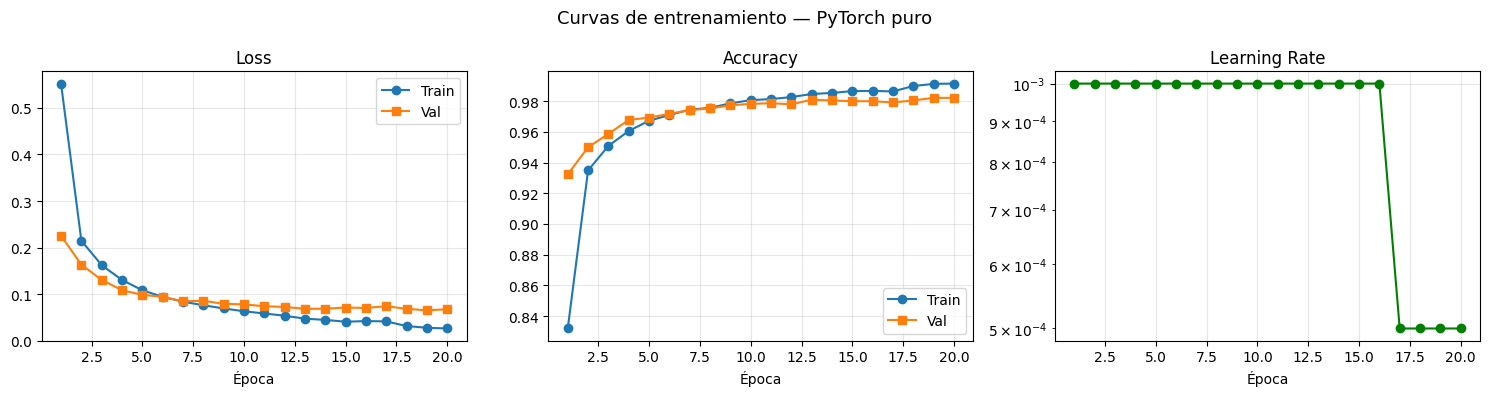

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(metrics['epoch'], metrics['train_loss'], label='Train', marker='o')
axes[0].plot(metrics['epoch'], metrics['val_loss'],   label='Val',   marker='s')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics['epoch'], metrics['train_acc'], label='Train', marker='o')
axes[1].plot(metrics['epoch'], metrics['val_acc'],   label='Val',   marker='s')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(metrics['epoch'], metrics['lr'], marker='o', color='green')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Época')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — PyTorch puro', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 12 — Inferencia con el mejor modelo

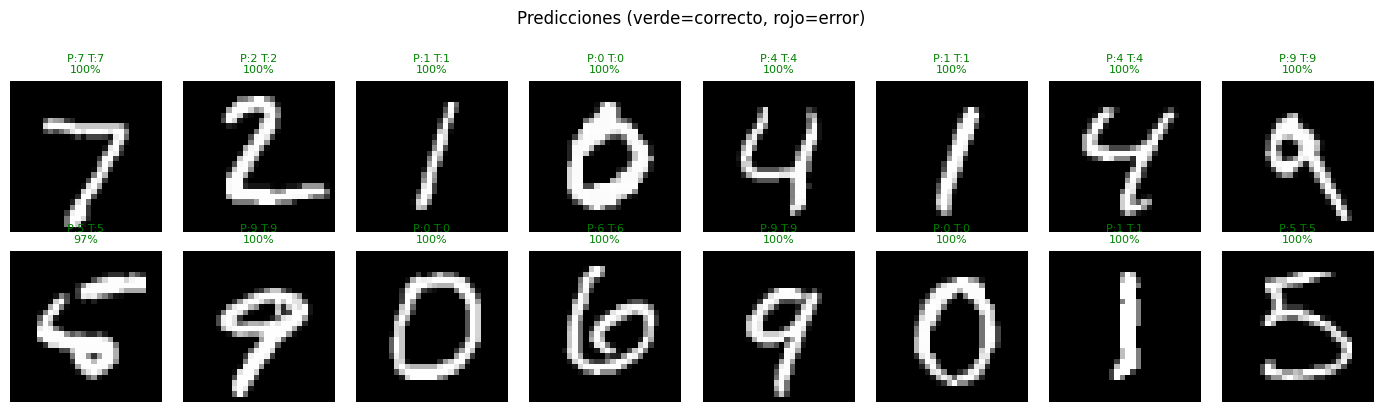

In [14]:
best_model.eval()
test_batch = next(iter(dm.test_dataloader()))
images, labels = test_batch
images = images.to(device)

with torch.no_grad():
    logits = best_model(images[:16])
    probs  = F.softmax(logits, dim=1)
    preds  = logits.argmax(dim=1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
    pred_label = preds[i].item()
    true_label = labels[i].item()
    confidence = probs[i, pred_label].item()
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'P:{pred_label} T:{true_label}\n{confidence:.0%}', color=color, fontsize=8)
    ax.axis('off')

plt.suptitle('Predicciones (verde=correcto, rojo=error)', y=1.02)
plt.tight_layout()
plt.show()

---
## Paso 13 — Comparar experimentos

Mismo ejercicio que en el tutorial de Lightning: entrenar con dos learning rates y comparar.

In [ ]:
results = {}

for lr in [1e-2, 1e-3]:
    seed_everything(42)

    run_model = MNISTClassifier().to(device)
    run_opt   = torch.optim.Adam(run_model.parameters(), lr=lr)
    run_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(run_opt, mode='min', factor=0.5, patience=3)
    run_es    = EarlyStopping(patience=3, mode='min')
    run_log   = CSVLogger(f'logs/lr_{lr}/metrics.csv')

    for epoch in range(1, 11):
        train_loss, train_acc = run_epoch(run_model, dm.train_dataloader(), run_opt, device)
        val_loss,   val_acc   = run_epoch(run_model, dm.val_dataloader(), None, device)
        run_sched.step(val_loss)
        run_log.log({'epoch': epoch, 'val_loss': round(val_loss, 4), 'val_acc': round(val_acc, 4)})
        if run_es.step(val_loss):
            break

    run_log.save()
    test_loss, test_acc = run_epoch(run_model, dm.test_dataloader(), None, device)
    results[f'lr={lr}'] = round(test_acc, 4)
    print(f'lr={lr}  →  test_acc={test_acc:.4f}')

print('\nResumen:', results)

---
## Resumen: PyTorch puro vs. Lightning

```
PyTorch Puro                          Lightning
─────────────────────────────────     ───────────────────────────
seed_everything()          →          pl.seed_everything()
device = torch.device()    →          Trainer(accelerator='auto')
model.to(device)           →          automático
MNISTDataModule (clase)    →          LightningDataModule
MNISTClassifier(nn.Module) →          LightningModule
optimizer = Adam(...)      →          configure_optimizers()
scheduler = ReduceLR(...)  →          configure_optimizers()
EarlyStopping (clase)      →          EarlyStopping callback
ModelCheckpoint (clase)    →          ModelCheckpoint callback
CSVLogger (clase)          →          CSVLogger
for epoch in range(...)    →          trainer.fit()
  model.train()            →          automático
  images.to(device)        →          automático
  zero_grad/backward/step  →          automático
  clip_grad_norm_()        →          Trainer(gradient_clip_val=)
  model.eval()             →          automático
  torch.no_grad()          →          automático
  scheduler.step()         →          automático
  early_stopping.step()    →          automático
  checkpoint_cb.step()     →          automático
torch.load() + load_state  →          load_from_checkpoint()
trainer.test()             →          run_epoch() en test set
```

### ¿Cuándo usar cada uno?

| Usa **PyTorch puro** cuando... | Usa **Lightning** cuando... |
|---|---|
| Estás aprendiendo y quieres entender cada paso | Quieres iterar rápido en experimentos |
| Necesitas un loop personalizado (RL, GANs, meta-learning) | El proyecto escala a multi-GPU o TPU |
| Tienes restricciones de dependencias | Trabajas en equipo con código estandarizado |
| Investigación que requiere control total | Producción con logging y checkpointing robusto |